# QF 627 Programming and Computational Finance
## Problem Set `4` | `In Progress` Part `2`

> "Hi Team! 👋

> The current notebook contains 8 questions that help you review our course content.

> Each question asks you to answer with specific results. Some questions are the `reverse-engineering-type` questions as I have asked in exercise problem set 3. Other questions require direct answers (because, given the nature of the question, reverse-engineering is not feasible).

> These questions won’t be difficult to solve—and working through them will strengthen your understanding of the learning materials. This week’s questions ask you to preview the lecture note script for Lesson 4, which we will continue in Lesson 5, and then attempt to answer the exercises.

> This preview exercise will help you consolidate the upcoming lessons more effectively. Once you have completed it, please submit your script via eLearn.

> Enjoy!"

##### First, let's do some quick exercise with stock prices data.

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

In [2]:
def compute_drawdown(cumulative_returns):
    max_gross_performance = cumulative_returns.cummax()
    return max_gross_performance - cumulative_returns

In [3]:
def compute_max_drawdown(cumualtive_returns):
    return compute_drawdown(cumualtive_returns).max()

In [4]:
def compute_longest_drawdown_period(cumulative_returns):
    drawdown = compute_drawdown(cumulative_returns)
    periods =\
    (
        np
        .diff(np.append(drawdown[drawdown == 0].index,
                        drawdown.index[-1: ]
                       )
             )
    )
    return periods.max() / np.timedelta64(1, "D")

In [5]:
def compute_sharpe_ratio(daily_returns):
    """
    Calculate the annualized Sharpe ratio from a series of daily returns.
    Annualized Sharpe ratio computed as:
                sqrt(252) * mean(daily_returns) / std(daily_returns)
    - Assumes 252 trading days per year for annualization. Adjust the
      multiplier for a different convention.
    - Input should be returns (not prices). Convert prices to returns before
      calling this function.
    Parameters:
        daily_returns : array-like (pd.Series or np.ndarray)
    Returns:
        float
    Usage:
        compute_sharpe_ratio(df['strategy_returns'])
    """
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std()

# compute_sharpe_ratio(ibm['strategy_returns'])

In [6]:
def compute_CAGR(cumulative_returns):
    """
    Compute Compound Annual Growth Rate (CAGR) from a series of cumulative returns.
        - The function drops missing values and uses the first and last available
      observations to compute CAGR as:
          (last_value / first_value) ** (365.0 / n_days) - 1
      where n_days is the integer number of days between the first and last index.
        - Uses 365-day convention for annualization. For trading-day conventions
        adjust the exponent accordingly.
        - If the series contains a single observation or zero-day span, the result
        may be ill-defined (division by zero or power of inf). Consider checking
        the index span before calling.
    Parameters:
        cumulative_returns : pandas.Series. Time-indexed series of cumulative returns (e.g. cumulative growth factors)
    Returns:
        float
    """

    cumulative_returns = cumulative_returns.dropna()
    n_of_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]
                ).days
    cagr =\
    (
        (        
        cumulative_returns.iloc[-1] 
        /
        cumulative_returns.iloc[0]
        ) ** (365.0 / n_of_days)
        - 1
    )
    return cagr

> Let's set some print option.

In [7]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

In [8]:
%whos

Variable                          Type        Data/Info
-------------------------------------------------------
compute_CAGR                      function    <function compute_CAGR at 0x135250540>
compute_drawdown                  function    <function compute_drawdown at 0x13523f2e0>
compute_longest_drawdown_period   function    <function compute_longest<...>wn_period at 0x13523f560>
compute_max_drawdown              function    <function compute_max_drawdown at 0x13523f4c0>
compute_sharpe_ratio              function    <function compute_sharpe_ratio at 0x135250360>
dt                                module      <module 'datetime' from '<...>/python3.12/datetime.py'>
mpl                               module      <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np                                module      Shape: <function shape at 0x1068a3ba0>
pd                                module      <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
pdr                               m

### <font color = red> Question 1</font>. Please import historical stock data from the web on the following financial instruments, and create the following DataFrame that contains adjusted closing prices. 

### Here, the timeframe should be set between the 13th of October 2014 through the 13th of September 2022 (nine years of data).

- `WMT` Stock of Walmart
- `IBM` Stock of IBM

In [9]:
start = "2014-10-13"
end = "2022-09-14"

ibm =\
(
    yf
    .download("IBM",
              start, 
              end)
    ["Close"]
)

ibm

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_43642/392819513.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  .download("IBM",
[*********************100%***********************]  1 of 1 completed


Ticker,IBM
Date,
2014-10-13,110.969681
2014-10-14,111.138977
2014-10-15,109.899414
2014-10-16,108.744469
2014-10-17,110.080772
...,...
2022-09-07,113.740074
2022-09-08,114.416939
2022-09-09,115.058182


### <font color = red> Question 2</font>. Please run a simple moving average crossover strategy for `IBM`.

### The two moving windows are 20 and 60 days.

### Please show your positions with a plot.

In [10]:
short, long = 20, 60

In [11]:
ibm["sma_20"] =\
(
    ibm["IBM"]
    .rolling(window = short)
    .mean()
)

In [12]:
ibm.isnull().sum()

Ticker
IBM        0
sma_20    19
dtype: int64

In [13]:
ibm["sma_60"] =\
(
    ibm["IBM"]
    .rolling(window = long)
    .mean()
)

In [14]:
(
    ibm
    .isnull() # bool
    .sum(axis = 0)
)

Ticker
IBM        0
sma_20    19
sma_60    59
dtype: int64

In [15]:
list_of_window = [22, 68]

In [16]:
for each_window in list_of_window:
    ibm[f"sma_{each_window}"] =\
    (
        ibm
        ["IBM"]
        .rolling(window = each_window)
        .mean()
    )

In [17]:
(
    ibm
    .isnull()
    .sum()
)

Ticker
IBM        0
sma_20    19
sma_60    59
sma_22    21
sma_68    67
dtype: int64

In [18]:
ibm

Ticker,IBM,sma_20,sma_60,sma_22,sma_68
Date,,,,,
2014-10-13,110.969681,NaN,NaN,NaN,NaN
2014-10-14,111.138977,NaN,NaN,NaN,NaN
2014-10-15,109.899414,NaN,NaN,NaN,NaN
2014-10-16,108.744469,NaN,NaN,NaN,NaN
2014-10-17,110.080772,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2022-09-07,113.740074,118.133907,118.805319,117.937284,119.332719
2022-09-08,114.416939,117.998979,118.731711,117.836483,119.211895
2022-09-09,115.058182,117.849802,118.659850,117.825148,119.091188


### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

In [19]:
ibm["trading_position"] =\
(
    np
    .where(ibm["sma_20"] > ibm["sma_60"],
           1, -1)
)

ibm = ibm.dropna()

ibm

Ticker,IBM,sma_20,sma_60,sma_22,sma_68,trading_position
Date,,,,,,
2015-01-20,95.553024,96.657416,97.644956,96.438298,98.651646,-1
2015-01-21,92.594208,96.461988,97.553760,96.442726,98.381418,-1
2015-01-22,94.603264,96.277821,97.497056,96.379354,98.138246,-1
2015-01-23,94.895523,96.083913,97.447340,96.306297,97.917600,-1
2015-01-26,95.193871,95.917709,97.385162,96.165719,97.718327,-1
...,...,...,...,...,...,...
2022-09-07,113.740074,118.133907,118.805319,117.937284,119.332719,-1
2022-09-08,114.416939,117.998979,118.731711,117.836483,119.211895,-1
2022-09-09,115.058182,117.849802,118.659850,117.825148,119.091188,-1


In [20]:
ibm.columns

Index(['IBM', 'sma_20', 'sma_60', 'sma_22', 'sma_68', 'trading_position'], dtype='object', name='Ticker')

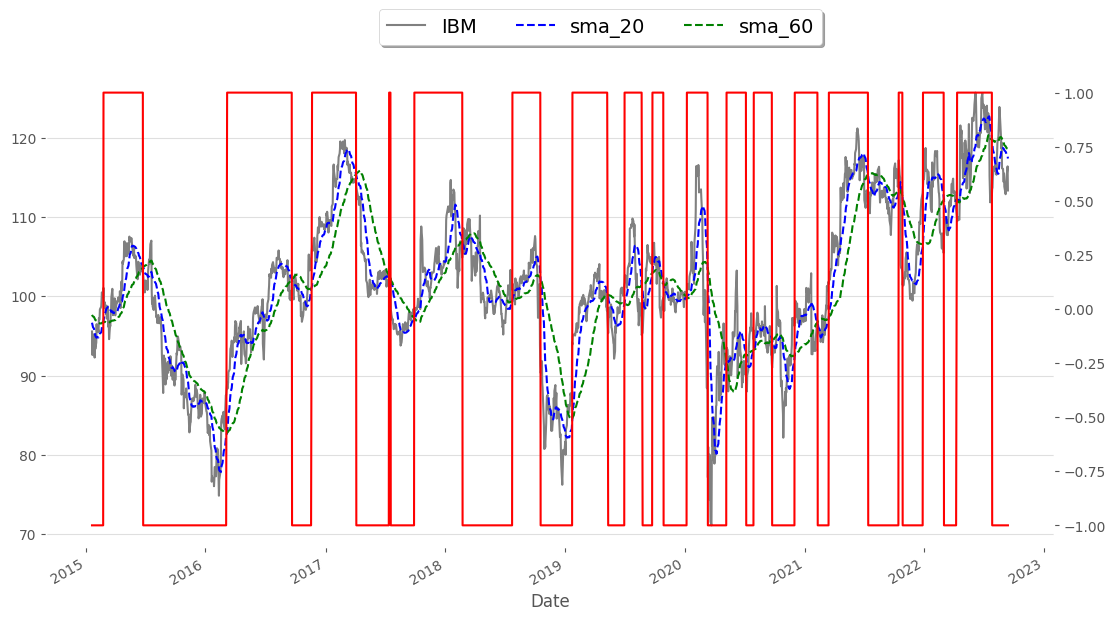

In [21]:
# TODO get_plot matplotlib; secondary y  axis

ax =\
(
    ibm
    [["IBM", "sma_20", "sma_60", "trading_position"]]
    .plot(secondary_y = "trading_position",
          style = ["grey", "b--", "g--", "r"],
          figsize = [13, 7]
         )
)

ax.xaxis.grid(False)

(
    ax
    .legend(loc = "upper center",
            bbox_to_anchor = (0.55, 1.15),
            ncol = 4,
            shadow = True
           )
)

In [22]:
ibm

Ticker,IBM,sma_20,sma_60,sma_22,sma_68,trading_position
Date,,,,,,
2015-01-20,95.553024,96.657416,97.644956,96.438298,98.651646,-1
2015-01-21,92.594208,96.461988,97.553760,96.442726,98.381418,-1
2015-01-22,94.603264,96.277821,97.497056,96.379354,98.138246,-1
2015-01-23,94.895523,96.083913,97.447340,96.306297,97.917600,-1
2015-01-26,95.193871,95.917709,97.385162,96.165719,97.718327,-1
...,...,...,...,...,...,...
2022-09-07,113.740074,118.133907,118.805319,117.937284,119.332719,-1
2022-09-08,114.416939,117.998979,118.731711,117.836483,119.211895,-1
2022-09-09,115.058182,117.849802,118.659850,117.825148,119.091188,-1


### <font color = red> Question 3</font>. Based on your lines of codes that lead to answer 2 above, compare the returns to see if the strategy leads to a win over the passive benchmark investment.

In [23]:
ibm["buy_hold_returns"] =\
(
    np
    .log(
        ibm["IBM"]
        /
        ibm["IBM"].shift(1)
    )
)

ibm["strategy_returns"] =\
(
    ibm["trading_position"] # target position
    .shift(1) # executed position
    *
    ibm["buy_hold_returns"]
)

# Team, the resultant DataFrame will have missing values for the first obs. of the two columns of returns
ibm.head(2)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_43642/685503336.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm["buy_hold_returns"] =\
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_43642/685503336.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm["strategy_returns"] =\


Ticker,IBM,sma_20,sma_60,sma_22,sma_68,trading_position,buy_hold_returns,strategy_returns
Date,,,,,,,,
2015-01-20,95.553024,96.657416,97.644956,96.438298,98.651646,-1,NaN,NaN
2015-01-21,92.594208,96.461988,97.553760,96.442726,98.381418,-1,-0.031455,0.031455


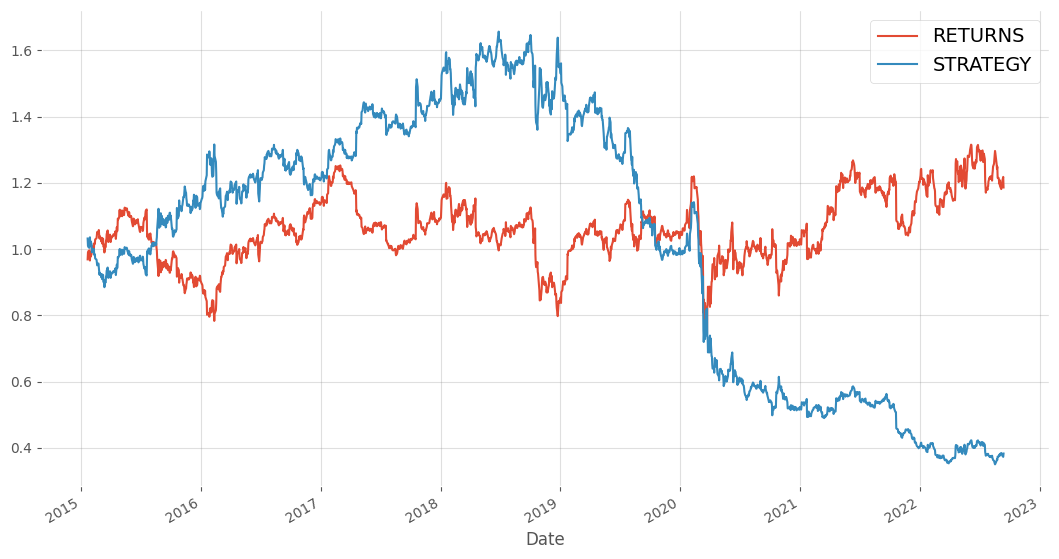

In [24]:
ax =\
(
    ibm[["buy_hold_returns", "strategy_returns"]]    
    .cumsum()
    .apply(np.exp)
    .plot(figsize = [13, 7]
         )
)

ax.legend(labels = ["RETURNS", "STRATEGY"]
         )

### <font color = red> Question 4</font>. Based on your lines of codes that lead to answer 3 above, please calculate the maximum drawdown and the longest drawdown period.

In [25]:
%whos

Variable                          Type         Data/Info
--------------------------------------------------------
ax                                Axes         Axes(0.125,0.2;0.775x0.68)
compute_CAGR                      function     <function compute_CAGR at 0x135250540>
compute_drawdown                  function     <function compute_drawdown at 0x13523f2e0>
compute_longest_drawdown_period   function     <function compute_longest<...>wn_period at 0x13523f560>
compute_max_drawdown              function     <function compute_max_drawdown at 0x13523f4c0>
compute_sharpe_ratio              function     <function compute_sharpe_ratio at 0x135250360>
dt                                module       <module 'datetime' from '<...>/python3.12/datetime.py'>
each_window                       int          68
end                               str          2022-09-14
ibm                               DataFrame    Shape: (1927, 8)
list_of_window                    list         n=2
long               

In [26]:
ibm["cumulative_returns"] =\
(
    ibm # DF
    ["strategy_returns"] # Series of interest
    .cumsum() # cumulative summation
    .apply(np.exp) # bring the log returns to original returns
)#.head()

ibm["max_gross_performance"] =\
(
    ibm["cumulative_returns"]
    .cummax()
)

ibm.head()

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_43642/1106527006.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm["cumulative_returns"] =\
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_43642/1106527006.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm["max_gross_performance"] =\


Ticker,IBM,sma_20,sma_60,sma_22,sma_68,trading_position,buy_hold_returns,strategy_returns,cumulative_returns,max_gross_performance
Date,,,,,,,,,,
2015-01-20,95.553024,96.657416,97.644956,96.438298,98.651646,-1,NaN,NaN,NaN,NaN
2015-01-21,92.594208,96.461988,97.553760,96.442726,98.381418,-1,-0.031455,0.031455,1.031955,1.031955
2015-01-22,94.603264,96.277821,97.497056,96.379354,98.138246,-1,0.021465,-0.021465,1.010039,1.031955
2015-01-23,94.895523,96.083913,97.447340,96.306297,97.917600,-1,0.003085,-0.003085,1.006929,1.031955
2015-01-26,95.193871,95.917709,97.385162,96.165719,97.718327,-1,0.003139,-0.003139,1.003773,1.031955


In [27]:
ibm.columns

Index(['IBM', 'sma_20', 'sma_60', 'sma_22', 'sma_68', 'trading_position',
       'buy_hold_returns', 'strategy_returns', 'cumulative_returns',
       'max_gross_performance'],
      dtype='object', name='Ticker')

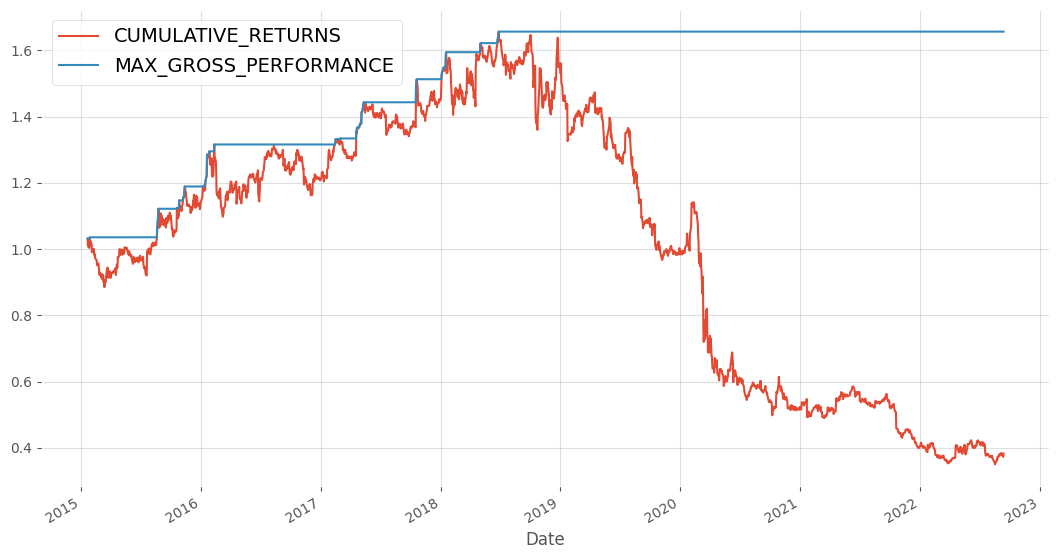

In [28]:
plot_object =\
(
    ibm
    [['cumulative_returns',
       'max_gross_performance']]
    .plot(figsize = [13, 7]
         )
)

plot_object.legend(labels = ["CUMULATIVE_RETURNS", "MAX_GROSS_PERFORMANCE"]
                  )

In [29]:
%whos

Variable                          Type         Data/Info
--------------------------------------------------------
ax                                Axes         Axes(0.125,0.2;0.775x0.68)
compute_CAGR                      function     <function compute_CAGR at 0x135250540>
compute_drawdown                  function     <function compute_drawdown at 0x13523f2e0>
compute_longest_drawdown_period   function     <function compute_longest<...>wn_period at 0x13523f560>
compute_max_drawdown              function     <function compute_max_drawdown at 0x13523f4c0>
compute_sharpe_ratio              function     <function compute_sharpe_ratio at 0x135250360>
dt                                module       <module 'datetime' from '<...>/python3.12/datetime.py'>
each_window                       int          68
end                               str          2022-09-14
ibm                               DataFrame    Shape: (1927, 10)
list_of_window                    list         n=2
long              

In [30]:
compute_max_drawdown(ibm["cumulative_returns"]
                    )

np.float64(1.3059895887875266)

In [31]:
def compute_drawdown_in_percent(cumulative_returns):
    max_gross_performance = cumulative_returns.cummax()
    drawdown = (max_gross_performance - cumulative_returns) / max_gross_performance
    return drawdown

In [32]:
compute_drawdown_in_percent(ibm["cumulative_returns"]
                           ).max()

np.float64(0.7884464711542583)

In [33]:
ibm['cumulative_returns']

Date
2015-01-20         NaN
2015-01-21    1.031955
2015-01-22    1.010039
2015-01-23    1.006929
2015-01-26    1.003773
                ...   
2022-09-07    0.381589
2022-09-08    0.379332
2022-09-09    0.377218
2022-09-12    0.372974
2022-09-13    0.382969
Name: cumulative_returns, Length: 1927, dtype: float64

In [34]:
compute_longest_drawdown_period(ibm["cumulative_returns"]
                               )

np.float64(1539.0)

### Please make sure to answer below.

    The maximum drawdown is NOT ___130___ percentage points, which is impossible.

    The maximum drawdown is about ___78%____.
    
    The longest drawdown period lasts for _____1539______ days.

### <font color = red> Question 5</font>. Now let’s have a look at the stock price of Walmart (WMT). Please run a simple moving average crossover strategy.

### The two moving windows are 50 and 200 days.

### Now, please visualize your buy positions using red dots, and your sell positions using blue dots.

### Then, please come up with an answer for the question below.

    Based on simple moving average crossover strategy, there were _______ trading opportunities found.

### <font color = red> Question 6</font> Please draw the strategy returns as shown below.

### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

### <font color = red> Question 7</font>. Please calculate the Sharpe Ratio of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a Sharpe ratio of _________ . 

    Simple moving strategy for WMT leads to a Sharpe ratio of _________ . 

### <font color = red> Question 8</font>. Please calculate the Compound Annual Growth Rate (CAGR) of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a CAGR of _________ .

    Simple moving strategy for WMT leads to a CAGR of _________ .


### <font color="green">"Thank you for putting your efforts into the exercise problem sets 💯"</font>